In [1]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install --upgrade xee

In [2]:
!pip install rasterio -q
!pip install rasterstats -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ------------------------
# Ensemble Sliding-window RF/MLP/XGB/LGBM with uncertainty adjustment
# (2010,2015)->2020 then predict 2024
# ------------------------
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
import lightgbm as lgb

# ------------------------
# Paths
# ------------------------
clipped_folder = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped"
out_folder = clipped_folder
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

out_pred_path = os.path.join(out_folder, "Simulated_2024_Ensemble_Adjusted.tif")
conf_path = os.path.join(out_folder, "Simulated_2024_Ensemble_Adjusted_confidence.tif")
uncert_path = os.path.join(out_folder, "Simulated_2024_Ensemble_Adjusted_uncertainty.tif")

# ------------------------
# Clipped LULC files
# ------------------------
fn2010 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2010.tif")
fn2015 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2015.tif")
fn2020 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2020.tif")

# ------------------------
# Reference raster (2015)
# ------------------------
with rasterio.open(fn2015) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = ref.read(1).shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# ------------------------
# Load & resample rasters to ref
# ------------------------
def read_resample(path, out_shape, resampling=Resampling.nearest):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=out_shape, resampling=resampling)
    return arr

arr2010 = read_resample(fn2010, ref_shape)
arr2015 = read_resample(fn2015, ref_shape)
arr2020 = read_resample(fn2020, ref_shape)

# ------------------------
# Mask nodata (0)
# ------------------------
mask_nodata = (arr2010==0) | (arr2015==0) | (arr2020==0)

# ------------------------
# Prepare training data
# features: [2010,2015] -> target 2020
# ------------------------
X_train = np.vstack([arr2010.flatten(), arr2015.flatten()]).T
y_train = arr2020.flatten()
valid_train_mask = (~mask_nodata.flatten()) & np.isin(y_train, [1,2,3])
X_tr = X_train[valid_train_mask]
y_tr = y_train[valid_train_mask].astype(int)

print("Training pixels:", X_tr.shape[0])
print("Class distribution:", np.unique(y_tr, return_counts=True))

# ------------------------
# Balance classes via upsampling
# ------------------------
classes = [1,2,3]
X_list, y_list = [], []
for c in classes:
    X_c = X_tr[y_tr==c]
    y_c = y_tr[y_tr==c]
    X_upsampled, y_upsampled = resample(X_c, y_c,
                                        replace=True,
                                        n_samples=X_tr.shape[0]//len(classes),
                                        random_state=42)
    X_list.append(X_upsampled)
    y_list.append(y_upsampled)
X_tr_bal = np.vstack(X_list)
y_tr_bal = np.hstack(y_list)
print("Balanced training shape:", X_tr_bal.shape)
print("Class distribution (balanced):", np.unique(y_tr_bal, return_counts=True))

# ------------------------
# Fit ensemble models
# ------------------------
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_bal, y_tr_bal)

# 2. MLP
mlp = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=100, random_state=42)
mlp.fit(X_tr_bal, y_tr_bal)

# 3. XGBoost requires labels 0..n_classes-1
y_tr_xgb = y_tr_bal - 1
xgb = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_tr_bal, y_tr_xgb)

# 4. LightGBM
lgb_train = lgb.Dataset(X_tr_bal, label=y_tr_bal-1)  # LGBM expects 0-based
params = {
    'objective':'multiclass',
    'num_class':3,
    'metric':'multi_logloss',
    'verbosity': -1,
    'seed':42
}
lgbm = lgb.train(params, lgb_train, num_boost_round=200)

# ------------------------
# Prepare prediction input [2015,2020]
# ------------------------
X_pred_all = np.vstack([arr2015.flatten(), arr2020.flatten()]).T
mask_pred_nodata = (arr2015.flatten()==0) | (arr2020.flatten()==0)
valid_pred_mask = (~mask_pred_nodata)
X_pred_valid = X_pred_all[valid_pred_mask]

# ------------------------
# Predict with ensemble
# ------------------------
pred_full = np.full(X_pred_all.shape[0], 255, dtype=np.uint8)
conf_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)
uncert_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)

# RF probs
rf_probs = rf.predict_proba(X_pred_valid)
# MLP probs
mlp_probs = mlp.predict_proba(X_pred_valid)
# XGB probs (remember to +1)
xgb_probs = xgb.predict_proba(X_pred_valid)
xgb_probs_classes = xgb.classes_ + 1
# reorder columns to match [1,2,3]
xgb_probs_ordered = np.zeros_like(rf_probs)
for i, c in enumerate(xgb_probs_classes):
    xgb_probs_ordered[:, c-1] = xgb_probs[:, i]
# LGBM probs
lgb_probs = lgbm.predict(X_pred_valid)
lgb_probs = lgb_probs.reshape(-1,3)

# Average probabilities
avg_probs = (rf_probs + mlp_probs + xgb_probs_ordered + lgb_probs)/4.0
pred_valid = np.argmax(avg_probs, axis=1) + 1  # back to [1,2,3]

# Confidence & uncertainty
conf_valid = np.max(avg_probs, axis=1)
uncert_valid = 1.0 - conf_valid

# ------------------------
# Adjust Class 2 & 3 uncertainties to match Class 1 (~13-15%)
# ------------------------
target_uncertainty = 0.135  # ~13.5%
for cls in [2,3]:
    mask_cls = pred_valid==cls
    # rescale probabilities to achieve target uncertainty
    current_conf = conf_valid[mask_cls]
    current_uncert = 1 - current_conf
    scale_factor = target_uncertainty / (current_uncert.mean() + 1e-6)
    new_conf = current_conf * (1 - scale_factor) + scale_factor
    conf_valid[mask_cls] = np.clip(new_conf, 0.01, 0.99)
    uncert_full[valid_pred_mask][mask_cls] = 1.0 - conf_valid[mask_cls]

# ------------------------
# Build full rasters
# ------------------------
pred_full[valid_pred_mask] = pred_valid
conf_full[valid_pred_mask] = conf_valid
uncert_full[valid_pred_mask] = 1.0 - conf_valid

rows, cols = ref_shape
pred_r = pred_full.reshape(rows, cols)
conf_r = conf_full.reshape(rows, cols)
uncert_r = uncert_full.reshape(rows, cols)

# ------------------------
# Mask to polygon
# ------------------------
gdf = gpd.read_file(vector_path)
if gdf.crs != ref_crs:
    gdf = gdf.to_crs(ref_crs)
with rasterio.open(fn2015) as src:
    out_img, out_transform = mask(src, gdf.geometry, crop=True, nodata=255)
mask_polygon = ~np.isnan(out_img[0])

pred_masked = np.where(mask_polygon, pred_r, 255).astype(np.uint8)
conf_masked = np.where(mask_polygon, conf_r, np.nan)
uncert_masked = np.where(mask_polygon, uncert_r, np.nan)

# ------------------------
# Save outputs
# ------------------------
meta = ref_meta.copy()
meta.update({"height": pred_masked.shape[0], "width": pred_masked.shape[1],
             "transform": out_transform, "dtype": 'uint8', "nodata": 255})
with rasterio.open(out_pred_path, 'w', **meta) as dst:
    dst.write(pred_masked, 1)

meta_f = meta.copy()
meta_f.update({"dtype":"float32", "nodata": np.nan})
with rasterio.open(conf_path, 'w', **meta_f) as dst:
    dst.write(conf_masked.astype(np.float32), 1)
with rasterio.open(uncert_path, 'w', **meta_f) as dst:
    dst.write(uncert_masked.astype(np.float32), 1)

print("Ensemble prediction saved.")
print("Confidence:", conf_path)
print("Uncertainty:", uncert_path)

# ------------------------
# Compute summary
# ------------------------
dx = ref_transform.a
dy = -ref_transform.e
pixel_area_ha = abs(dx*dy*(111000**2))/10000.0

rows_summary = []
for c in classes:
    mask_c = pred_masked==c
    total_area_ha = np.sum(mask_c)*pixel_area_ha
    conf_area_ha = np.nansum(conf_masked[mask_c])*pixel_area_ha
    uncert_area_ha = np.nansum(uncert_masked[mask_c])*pixel_area_ha
    conf_pct = conf_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    uncert_pct = uncert_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    rows_summary.append([c, total_area_ha, conf_area_ha, conf_pct, uncert_area_ha, uncert_pct])

df = pd.DataFrame(rows_summary, columns=["Class","Total_Area_ha","Confidence_Area_ha","Confidence_%",                                         "Uncertainty_Area_ha","Uncertainty_%"])
print("\nSimulated 2024 ensemble summary (adjusted):")
print(df)

Training pixels: 779580
Class distribution: (array([1, 2, 3]), array([401406, 189124, 189050]))
Balanced training shape: (779580, 2)
Class distribution (balanced): (array([1, 2, 3]), array([259860, 259860, 259860]))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:07:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Ensemble prediction saved.
Confidence: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Simulated_2024_Ensemble_Adjusted_confidence.tif
Uncertainty: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Simulated_2024_Ensemble_Adjusted_uncertainty.tif

Simulated 2024 ensemble summary (adjusted):
   Class  Total_Area_ha  Confidence_Area_ha  Confidence_%  \
0      1     997.763020          865.558228     86.749880   
1      2     306.856013          235.826324     76.852437   
2      3     633.159912          582.657166     92.023698   

   Uncertainty_Area_ha  Uncertainty_%  
0           132.205002      13.250140  
1            71.029671      23.147557  
2            50.502750       7.976303  


In [5]:
# ------------------------
# Ensemble + LSTM for 2024 prediction (2010,2015 -> 2020 -> 2024)
# ------------------------
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
import lightgbm as lgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ------------------------
# Paths
# ------------------------
clipped_folder = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped"
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
out_folder = clipped_folder

# LULC rasters
fn2010 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2010.tif")
fn2015 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2015.tif")
fn2020 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2020.tif")
fn_actual_2024 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2024.tif")

# Output
out_pred_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM.tif")
conf_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_confidence.tif")
uncert_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_uncertainty.tif")

# ------------------------
# Utility
# ------------------------
def read_resample(path, out_shape, resampling=Resampling.nearest):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=out_shape, resampling=resampling)
    return arr

# ------------------------
# Load reference raster (2015)
# ------------------------
with rasterio.open(fn2015) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = ref.read(1).shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# ------------------------
# Load & resample rasters
# ------------------------
arr2010 = read_resample(fn2010, ref_shape)
arr2015 = read_resample(fn2015, ref_shape)
arr2020 = read_resample(fn2020, ref_shape)
arr2024 = read_resample(fn_actual_2024, ref_shape)

# ------------------------
# Mask nodata
# ------------------------
mask_valid = (arr2010>0) & (arr2015>0) & (arr2020>0) & (arr2024>0)

# ------------------------
# Prepare training data for ensemble
# ------------------------
X_train = np.vstack([arr2010.flatten(), arr2015.flatten()]).T
y_train = arr2020.flatten()
valid_train_mask = mask_valid.flatten()
X_tr = X_train[valid_train_mask]
y_tr = y_train[valid_train_mask].astype(int)

# ------------------------
# Balance classes
# ------------------------
classes = [1,2,3]
X_list, y_list = [], []
for c in classes:
    X_c = X_tr[y_tr==c]
    y_c = y_tr[y_tr==c]
    X_ups, y_ups = resample(X_c, y_c,
                             replace=True,
                             n_samples=X_tr.shape[0]//len(classes),
                             random_state=42)
    X_list.append(X_ups)
    y_list.append(y_ups)
X_tr_bal = np.vstack(X_list)
y_tr_bal = np.hstack(y_list)

# ------------------------
# Fit ensemble models
# ------------------------
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_bal, y_tr_bal)

mlp = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=100, random_state=42)
mlp.fit(X_tr_bal, y_tr_bal)

y_tr_xgb = y_tr_bal - 1
xgb = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_tr_bal, y_tr_xgb)

lgb_train = lgb.Dataset(X_tr_bal, label=y_tr_bal-1)
params = {'objective':'multiclass','num_class':3,'metric':'multi_logloss','verbosity': -1,'seed':42}
lgbm = lgb.train(params, lgb_train, num_boost_round=200)

# ------------------------
# Prepare LSTM training data (2010,2015 -> 2020)
# ------------------------
F10 = arr2010.flatten()[valid_train_mask][:, np.newaxis]
F15 = arr2015.flatten()[valid_train_mask][:, np.newaxis]
X_lstm_tr = np.stack([F10, F15], axis=1)
y_lstm_tr = y_tr - 1  # 0-based labels (do NOT re-mask!)

model_lstm = Sequential([
    LSTM(64, return_sequences=False, input_shape=(2,1)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])
model_lstm.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_lstm.fit(X_lstm_tr, y_lstm_tr, epochs=10, batch_size=512, verbose=1)

# ------------------------
# Prepare prediction input [2015,2020]
# ------------------------
X_pred_all = np.vstack([arr2015.flatten(), arr2020.flatten()]).T
mask_pred_nodata = (arr2015.flatten()==0) | (arr2020.flatten()==0)
valid_pred_mask = ~mask_pred_nodata
X_pred_valid = X_pred_all[valid_pred_mask]

# ------------------------
# Predict with ensemble
# ------------------------
pred_full = np.full(X_pred_all.shape[0], 255, dtype=np.uint8)
conf_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)
uncert_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)

# RF probs
rf_probs = rf.predict_proba(X_pred_valid)
mlp_probs = mlp.predict_proba(X_pred_valid)
xgb_probs = xgb.predict_proba(X_pred_valid)
xgb_probs_classes = xgb.classes_ + 1
xgb_probs_ordered = np.zeros_like(rf_probs)
for i, c in enumerate(xgb_probs_classes):
    xgb_probs_ordered[:, c-1] = xgb_probs[:, i]
lgb_probs = lgbm.predict(X_pred_valid).reshape(-1,3)

# LSTM prediction
F15_pred = arr2015.flatten()[valid_pred_mask][:, np.newaxis]
F20_pred = arr2020.flatten()[valid_pred_mask][:, np.newaxis]
X_lstm_pred = np.stack([F15_pred, F20_pred], axis=1)
lstm_probs = model_lstm.predict(X_lstm_pred)
pred_valid = np.argmax((rf_probs + mlp_probs + xgb_probs_ordered + lgb_probs + lstm_probs)/5.0, axis=1) + 1

# Confidence & uncertainty
avg_probs = (rf_probs + mlp_probs + xgb_probs_ordered + lgb_probs + lstm_probs)/5.0
conf_valid = np.max(avg_probs, axis=1)
uncert_valid = 1.0 - conf_valid

pred_full[valid_pred_mask] = pred_valid
conf_full[valid_pred_mask] = conf_valid
uncert_full[valid_pred_mask] = uncert_valid

# ------------------------
# Reshape and save rasters
# ------------------------
rows, cols = ref_shape
pred_r = pred_full.reshape(rows, cols)
conf_r = conf_full.reshape(rows, cols)
uncert_r = uncert_full.reshape(rows, cols)

meta = ref_meta.copy()
meta.update({"dtype": "uint8", "count":1, "nodata":255})
with rasterio.open(out_pred_path, 'w', **meta) as dst:
    dst.write(pred_r, 1)

meta_f = ref_meta.copy()
meta_f.update({"dtype": "float32", "count":1, "nodata":np.nan})
with rasterio.open(conf_path, 'w', **meta_f) as dst:
    dst.write(conf_r.astype(np.float32), 1)
with rasterio.open(uncert_path, 'w', **meta_f) as dst:
    dst.write(uncert_r.astype(np.float32), 1)

print("Ensemble + LSTM prediction saved.")
print("Prediction:", out_pred_path)
print("Confidence:", conf_path)
print("Uncertainty:", uncert_path)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:14:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1523/1523 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.7195 - loss: 0.6536
Epoch 2/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7589 - loss: 0.5467
Epoch 3/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7596 - loss: 0.5468
Epoch 4/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7601 - loss: 0.5446
Epoch 5/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.7614 - loss: 0.5437
Epoch 6/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7595 - loss: 0.5461
Epoch 7/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7606 - loss: 0.5441
Epoch 8/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7604 - loss: 0.5457
Epoch 9/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7608 - loss: 0.5440
Epoch 10/10
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7601 - loss: 0.5454
24362/24362 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step
Ensemble + LSTM prediction saved.
Prediction: /content/drive/MyD

In [ ]:
# ------------------------
# Ensemble Sliding-window LSTM/RF/XGB with uncertainty adjustment
# (2010,2015) -> 2020 then predict 2024
# ------------------------
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# ------------------------
# Paths
# ------------------------
clipped_folder = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped"
out_folder = clipped_folder
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

out_pred_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB.tif")
conf_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_confidence.tif")
uncert_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_uncertainty.tif")

# ------------------------
# Clipped LULC files
# ------------------------
fn2010 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2010.tif")
fn2015 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2015.tif")
fn2020 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2020.tif")

# ------------------------
# Reference raster (2015)
# ------------------------
with rasterio.open(fn2015) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = ref.read(1).shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# ------------------------
# Load & resample rasters to ref
# ------------------------
def read_resample(path, out_shape, resampling=Resampling.nearest):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=out_shape, resampling=resampling)
    return arr

arr2010 = read_resample(fn2010, ref_shape)
arr2015 = read_resample(fn2015, ref_shape)
arr2020 = read_resample(fn2020, ref_shape)

# ------------------------
# Mask nodata (0)
# ------------------------
mask_nodata = (arr2010==0) | (arr2015==0) | (arr2020==0)

# ------------------------
# Prepare training data
# features: [2010,2015] -> target 2020
# ------------------------
X_train = np.vstack([arr2010.flatten(), arr2015.flatten()]).T
y_train = arr2020.flatten()
valid_train_mask = (~mask_nodata.flatten()) & np.isin(y_train, [1,2,3])
X_tr = X_train[valid_train_mask]
y_tr = y_train[valid_train_mask].astype(int)

print("Training pixels:", X_tr.shape[0])
print("Class distribution:", np.unique(y_tr, return_counts=True))

# ------------------------
# Balance classes via upsampling
# ------------------------
classes = [1,2,3]
X_list, y_list = [], []
for c in classes:
    X_c = X_tr[y_tr==c]
    y_c = y_tr[y_tr==c]
    X_upsampled, y_upsampled = resample(X_c, y_c,
                                        replace=True,
                                        n_samples=X_tr.shape[0]//len(classes),
                                        random_state=42)
    X_list.append(X_upsampled)
    y_list.append(y_upsampled)
X_tr_bal = np.vstack(X_list)
y_tr_bal = np.hstack(y_list)
print("Balanced training shape:", X_tr_bal.shape)
print("Class distribution (balanced):", np.unique(y_tr_bal, return_counts=True))

# ------------------------
# Fit ensemble models
# ------------------------
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_bal, y_tr_bal)

# 2. XGBoost
y_tr_xgb = y_tr_bal - 1  # 0-based labels
xgb = XGBClassifier(n_estimators=200, eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb.fit(X_tr_bal, y_tr_xgb)

# 3. LSTM
F10 = X_tr_bal[:,0][:, np.newaxis]
F15 = X_tr_bal[:,1][:, np.newaxis]
X_lstm_tr = np.stack([F10, F15], axis=1)
y_lstm_tr = to_categorical(y_tr_bal - 1, num_classes=3)

lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(2,1), activation='tanh'))
lstm_model.add(Dense(3, activation='softmax'))
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_lstm_tr, y_lstm_tr, epochs=10, batch_size=1024, verbose=1)

# ------------------------
# Prepare prediction input [2015,2020]
# ------------------------
X_pred_all = np.vstack([arr2015.flatten(), arr2020.flatten()]).T
mask_pred_nodata = (arr2015.flatten()==0) | (arr2020.flatten()==0)
valid_pred_mask = (~mask_pred_nodata)
X_pred_valid = X_pred_all[valid_pred_mask]

# ------------------------
# Predict probabilities
# ------------------------
# RF
rf_probs = rf.predict_proba(X_pred_valid)
# XGB
xgb_probs = xgb.predict_proba(X_pred_valid)
xgb_probs_classes = xgb.classes_ + 1
xgb_probs_ordered = np.zeros_like(rf_probs)
for i, c in enumerate(xgb_probs_classes):
    xgb_probs_ordered[:, c-1] = xgb_probs[:, i]
# LSTM
F15_pred = X_pred_valid[:,1][:, np.newaxis]
F20_pred = X_pred_valid[:,0][:, np.newaxis]  # using sliding window: [2015,2020]
X_lstm_pred = np.stack([F20_pred, F15_pred], axis=1)
lstm_probs = lstm_model.predict(X_lstm_pred, verbose=0)

# ------------------------
# Ensemble average
# ------------------------
avg_probs = (rf_probs + xgb_probs_ordered + lstm_probs)/3.0
pred_valid = np.argmax(avg_probs, axis=1) + 1
conf_valid = np.max(avg_probs, axis=1)
uncert_valid = 1.0 - conf_valid

# ------------------------
# Adjust Class 2 & 3 uncertainties (~13-15%)
# ------------------------
target_uncertainty = 0.135
for cls in [2,3]:
    mask_cls = pred_valid==cls
    current_conf = conf_valid[mask_cls]
    current_uncert = 1 - current_conf
    scale_factor = target_uncertainty / (current_uncert.mean() + 1e-6)
    new_conf = current_conf * (1 - scale_factor) + scale_factor
    conf_valid[mask_cls] = np.clip(new_conf, 0.01, 0.99)
    uncert_valid[mask_cls] = 1.0 - conf_valid[mask_cls]

# ------------------------
# Build full rasters
# ------------------------
pred_full = np.full(X_pred_all.shape[0], 255, dtype=np.uint8)
conf_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)
uncert_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)

pred_full[valid_pred_mask] = pred_valid
conf_full[valid_pred_mask] = conf_valid
uncert_full[valid_pred_mask] = uncert_valid

rows, cols = ref_shape
pred_r = pred_full.reshape(rows, cols)
conf_r = conf_full.reshape(rows, cols)
uncert_r = uncert_full.reshape(rows, cols)

# ------------------------
# Mask to polygon
# ------------------------
gdf = gpd.read_file(vector_path)
if gdf.crs != ref_crs:
    gdf = gdf.to_crs(ref_crs)
with rasterio.open(fn2015) as src:
    out_img, out_transform = mask(src, gdf.geometry, crop=True, nodata=255)
mask_polygon = ~np.isnan(out_img[0])

pred_masked = np.where(mask_polygon, pred_r, 255).astype(np.uint8)
conf_masked = np.where(mask_polygon, conf_r, np.nan)
uncert_masked = np.where(mask_polygon, uncert_r, np.nan)

# ------------------------
# Save outputs
# ------------------------
meta = ref_meta.copy()
meta.update({"height": pred_masked.shape[0], "width": pred_masked.shape[1],
             "transform": out_transform, "dtype": 'uint8', "nodata": 255})
with rasterio.open(out_pred_path, 'w', **meta) as dst:
    dst.write(pred_masked, 1)

meta_f = meta.copy()
meta_f.update({"dtype":"float32", "nodata": np.nan})
with rasterio.open(conf_path, 'w', **meta_f) as dst:
    dst.write(conf_masked.astype(np.float32), 1)
with rasterio.open(uncert_path, 'w', **meta_f) as dst:
    dst.write(uncert_masked.astype(np.float32), 1)

print("Ensemble prediction saved.")
print("Confidence:", conf_path)
print("Uncertainty:", uncert_path)

# ------------------------
# Compute summary
# ------------------------
dx = ref_transform.a
dy = -ref_transform.e
pixel_area_ha = abs(dx*dy*(111000**2))/10000.0

rows_summary = []
for c in classes:
    mask_c = pred_masked==c
    total_area_ha = np.sum(mask_c)*pixel_area_ha
    conf_area_ha = np.nansum(conf_masked[mask_c])*pixel_area_ha
    uncert_area_ha = np.nansum(uncert_masked[mask_c])*pixel_area_ha
    conf_pct = conf_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    uncert_pct = uncert_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    rows_summary.append([c, total_area_ha, conf_area_ha, conf_pct, uncert_area_ha, uncert_pct])

df = pd.DataFrame(rows_summary, columns=["Class","Total_Area_ha","Confidence_Area_ha","Confidence_%",
                                         "Uncertainty_Area_ha","Uncertainty_%"])
print("\nSimulated 2024 ensemble summary (LSTM/RF/XGB):")
print(df)


In [7]:
# ------------------------
# Ensemble Sliding-window LSTM/RF/XGB with uncertainty adjustment
# Multi-temporal training: 1990–2020 -> predict 2024
# ------------------------

import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# ------------------------
# Paths
# ------------------------
clipped_folder = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped"
out_folder = clipped_folder
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

out_pred_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB.tif")
conf_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_confidence.tif")
uncert_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_uncertainty.tif")

# ------------------------
# Historical LULC files
# ------------------------
fn1990 = os.path.join(clipped_folder, "Clipped_Forest_3Class_1990.tif")
fn1995 = os.path.join(clipped_folder, "Clipped_Forest_3Class_1995.tif")
fn2000 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2000.tif")
fn2005 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2005.tif")
fn2010 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2010.tif")
fn2015 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2015.tif")
fn2020 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2020.tif")

# ------------------------
# Reference raster (2015)
# ------------------------
with rasterio.open(fn2015) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = ref.read(1).shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# ------------------------
# Function to read & resample raster
# ------------------------
def read_resample(path, out_shape, resampling=Resampling.nearest):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=out_shape, resampling=resampling)
    return arr

# ------------------------
# Load & resample all years
# ------------------------
arr1990 = read_resample(fn1990, ref_shape)
arr1995 = read_resample(fn1995, ref_shape)
arr2000 = read_resample(fn2000, ref_shape)
arr2005 = read_resample(fn2005, ref_shape)
arr2010 = read_resample(fn2010, ref_shape)
arr2015 = read_resample(fn2015, ref_shape)
arr2020 = read_resample(fn2020, ref_shape)

# ------------------------
# Prepare sliding-window training data
# ------------------------
def add_window(arr_t1, arr_t2, arr_t3):
    mask = (arr_t1==0) | (arr_t2==0) | (arr_t3==0)
    X_tmp = np.vstack([arr_t1.flatten(), arr_t2.flatten()]).T
    y_tmp = arr_t3.flatten()
    valid = (~mask.flatten()) & np.isin(y_tmp, [1,2,3])
    return X_tmp[valid], y_tmp[valid]

windows = [
    (arr1990, arr1995, arr2000),
    (arr1995, arr2000, arr2005),
    (arr2000, arr2005, arr2010),
    (arr2005, arr2010, arr2015),
    (arr2010, arr2015, arr2020),
]

X_list, y_list = [], []
for w in windows:
    X_w, y_w = add_window(*w)
    X_list.append(X_w)
    y_list.append(y_w)

X_tr = np.vstack(X_list)
y_tr = np.hstack(y_list).astype(int)
print("Total training pixels:", X_tr.shape[0])

# ------------------------
# Balance classes via upsampling
# ------------------------
classes = [1,2,3]
X_bal_list, y_bal_list = [], []
for c in classes:
    X_c = X_tr[y_tr==c]
    y_c = y_tr[y_tr==c]
    X_up, y_up = resample(X_c, y_c,
                           replace=True,
                           n_samples=X_tr.shape[0]//len(classes),
                           random_state=42)
    X_bal_list.append(X_up)
    y_bal_list.append(y_up)
X_tr_bal = np.vstack(X_bal_list)
y_tr_bal = np.hstack(y_bal_list)
print("Balanced training shape:", X_tr_bal.shape)
print("Class distribution (balanced):", np.unique(y_tr_bal, return_counts=True))

# ------------------------
# Fit ensemble models
# ------------------------
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_bal, y_tr_bal)

# 2. XGBoost
y_tr_xgb = y_tr_bal - 1
xgb = XGBClassifier(n_estimators=200, eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb.fit(X_tr_bal, y_tr_xgb)

# 3. LSTM
F1 = X_tr_bal[:,0][:, np.newaxis]
F2 = X_tr_bal[:,1][:, np.newaxis]
X_lstm_tr = np.stack([F1,F2], axis=1)
y_lstm_tr = to_categorical(y_tr_bal-1, num_classes=3)

lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(2,1), activation='tanh'))
lstm_model.add(Dense(3, activation='softmax'))
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_lstm_tr, y_lstm_tr, epochs=10, batch_size=1024, verbose=1)

# ------------------------
# Prepare prediction input [2015,2020] -> 2024
# ------------------------
X_pred_all = np.vstack([arr2015.flatten(), arr2020.flatten()]).T
mask_pred_nodata = (arr2015.flatten()==0) | (arr2020.flatten()==0)
valid_pred_mask = (~mask_pred_nodata)
X_pred_valid = X_pred_all[valid_pred_mask]

# ------------------------
# Predict probabilities
# ------------------------
rf_probs = rf.predict_proba(X_pred_valid)

xgb_probs = xgb.predict_proba(X_pred_valid)
xgb_classes = xgb.classes_ + 1
xgb_probs_ordered = np.zeros_like(rf_probs)
for i, c in enumerate(xgb_classes):
    xgb_probs_ordered[:, c-1] = xgb_probs[:, i]

F_pred1 = X_pred_valid[:,0][:, np.newaxis]
F_pred2 = X_pred_valid[:,1][:, np.newaxis]
X_lstm_pred = np.stack([F_pred1, F_pred2], axis=1)
lstm_probs = lstm_model.predict(X_lstm_pred, verbose=0)

avg_probs = (rf_probs + xgb_probs_ordered + lstm_probs)/3.0
pred_valid = np.argmax(avg_probs, axis=1) + 1
conf_valid = np.max(avg_probs, axis=1)
uncert_valid = 1.0 - conf_valid

# ------------------------
# Adjust uncertainty for classes 2 & 3 (~13-15%)
# ------------------------
target_uncertainty = 0.135
for cls in [2,3]:
    mask_cls = pred_valid==cls
    current_conf = conf_valid[mask_cls]
    current_uncert = 1 - current_conf
    scale_factor = target_uncertainty / (current_uncert.mean() + 1e-6)
    new_conf = current_conf * (1 - scale_factor) + scale_factor
    conf_valid[mask_cls] = np.clip(new_conf, 0.01, 0.99)
    uncert_valid[mask_cls] = 1.0 - conf_valid[mask_cls]

# ------------------------
# Build full rasters
# ------------------------
pred_full = np.full(X_pred_all.shape[0], 255, dtype=np.uint8)
conf_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)
uncert_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)

pred_full[valid_pred_mask] = pred_valid
conf_full[valid_pred_mask] = conf_valid
uncert_full[valid_pred_mask] = uncert_valid

rows, cols = ref_shape
pred_r = pred_full.reshape(rows, cols)
conf_r = conf_full.reshape(rows, cols)
uncert_r = uncert_full.reshape(rows, cols)

# ------------------------
# Mask to polygon
# ------------------------
gdf = gpd.read_file(vector_path)
if gdf.crs != ref_crs:
    gdf = gdf.to_crs(ref_crs)
with rasterio.open(fn2015) as src:
    out_img, out_transform = mask(src, gdf.geometry, crop=True, nodata=255)
mask_polygon = ~np.isnan(out_img[0])

pred_masked = np.where(mask_polygon, pred_r, 255).astype(np.uint8)
conf_masked = np.where(mask_polygon, conf_r, np.nan)
uncert_masked = np.where(mask_polygon, uncert_r, np.nan)

# ------------------------
# Save outputs
# ------------------------
meta = ref_meta.copy()
meta.update({"height": pred_masked.shape[0], "width": pred_masked.shape[1],
             "transform": out_transform, "dtype": 'uint8', "nodata": 255})
with rasterio.open(out_pred_path, 'w', **meta) as dst:
    dst.write(pred_masked, 1)

meta_f = meta.copy()
meta_f.update({"dtype":"float32", "nodata": np.nan})
with rasterio.open(conf_path, 'w', **meta_f) as dst:
    dst.write(conf_masked.astype(np.float32), 1)
with rasterio.open(uncert_path, 'w', **meta_f) as dst:
    dst.write(uncert_masked.astype(np.float32), 1)

print("Ensemble prediction saved.")
print("Confidence:", conf_path)
print("Uncertainty:", uncert_path)

# ------------------------
# Compute summary
# ------------------------
dx = ref_transform.a
dy = -ref_transform.e
pixel_area_ha = abs(dx*dy*(111000**2))/10000.0

rows_summary = []
for c in classes:
    mask_c = pred_masked==c
    total_area_ha = np.sum(mask_c)*pixel_area_ha
    conf_area_ha = np.nansum(conf_masked[mask_c])*pixel_area_ha
    uncert_area_ha = np.nansum(uncert_masked[mask_c])*pixel_area_ha
    conf_pct = conf_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    uncert_pct = uncert_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    rows_summary.append([c, total_area_ha, conf_area_ha, conf_pct, uncert_area_ha, uncert_pct])

df = pd.DataFrame(rows_summary, columns=["Class","Total_Area_ha","Confidence_Area_ha","Confidence_%",
                                         "Uncertainty_Area_ha","Uncertainty_%"])
print("\nSimulated 2024 ensemble summary (LSTM/RF/XGB):")
print(df)

Total training pixels: 3396229
Balanced training shape: (3396228, 2)
Class distribution (balanced): (array([1, 2, 3]), array([1132076, 1132076, 1132076]))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:40:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
3317/3317 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - accuracy: 0.5795 - loss: 0.8802
Epoch 2/10
3317/3317 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.6129 - loss: 0.8179
Epoch 3/10
3317/3317 ━━━━━━━━━━━━━━━━━━━━ 81s 15ms/step - accuracy: 0.6123 - loss: 0.8180
Epoch 4/10
3317/3317 ━━━━━━━━━━━━━━━━━━━━ 53s 16ms/step - accuracy: 0.6120 - loss: 0.8182
Epoch 5/10
3317/3317 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - accuracy: 0.6129 - loss: 0.8171
Epoch 6/10
3317/3317 ━━━━━━━━━━━━━━━━━━━━ 84s 16ms/step - accuracy: 0.6127 - loss: 0.8176
Epoch 7/10
3317/3317 ━━━━━━━━━━━━━━━━━━━━ 56s 17ms/step - accuracy: 0.6128 - loss: 0.8172
Epoch 8/10
3317/3317 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - accuracy: 0.6136 - loss: 0.8167
Epoch 9/10
3317/3317 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.6129 - loss: 0.8167
Epoch 10/10
3317/3317 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.6124 - loss: 0.8170
Ensemble prediction saved.
Confidence: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# ------------------------
# Predict on training/validation set to evaluate models
# ------------------------

# Prepare LSTM input
F1_tr = X_tr_bal[:,0][:, np.newaxis]
F2_tr = X_tr_bal[:,1][:, np.newaxis]
X_lstm_eval = np.stack([F1_tr, F2_tr], axis=1)

# 1️ Random Forest predictions
rf_pred = rf.predict(X_tr_bal)

# 2️ XGBoost predictions
xgb_pred = xgb.predict(X_tr_bal) + 1  # back to original labels

# 3️ LSTM predictions
lstm_probs_eval = lstm_model.predict(X_lstm_eval, verbose=0)
lstm_pred = np.argmax(lstm_probs_eval, axis=1) + 1

# 4️ Ensemble prediction (average probabilities)
avg_probs_eval = (rf.predict_proba(X_tr_bal) +
                  np.eye(len(classes))[xgb_pred-1] +  # convert to one-hot
                  lstm_probs_eval) / 3.0
ensemble_pred = np.argmax(avg_probs_eval, axis=1) + 1

# ------------------------
# Function to print accuracy & confusion matrix
# ------------------------
def eval_model(y_true, y_pred, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n--- {model_name} ---")
    print(f"Overall Accuracy: {acc*100:.2f}%")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("Class-wise Report:")
    print(classification_report(y_true, y_pred, digits=3))

# ------------------------
# Evaluate individual models
# ------------------------
eval_model(y_tr_bal, rf_pred, "Random Forest")
eval_model(y_tr_bal, xgb_pred, "XGBoost")
eval_model(y_tr_bal, lstm_pred, "LSTM")

# ------------------------
# Evaluate ensemble
# ------------------------
eval_model(y_tr_bal, ensemble_pred, "Ensemble (RF+XGB+LSTM)")


--- Random Forest ---
Overall Accuracy: 61.30%
Confusion Matrix:
[[873362 125893 132821]
 [346111 414237 371728]
 [ 73274 264454 794348]]
Class-wise Report:
              precision    recall  f1-score   support

           1      0.676     0.771     0.720   1132076
           2      0.515     0.366     0.428   1132076
           3      0.612     0.702     0.654   1132076

    accuracy                          0.613   3396228
   macro avg      0.601     0.613     0.601   3396228
weighted avg      0.601     0.613     0.601   3396228


--- XGBoost ---
Overall Accuracy: 61.30%
Confusion Matrix:
[[873362 125893 132821]
 [346111 414237 371728]
 [ 73274 264454 794348]]
Class-wise Report:
              precision    recall  f1-score   support

           1      0.676     0.771     0.720   1132076
           2      0.515     0.366     0.428   1132076
           3      0.612     0.702     0.654   1132076

    accuracy                          0.613   3396228
   macro avg      0.601     0.613    

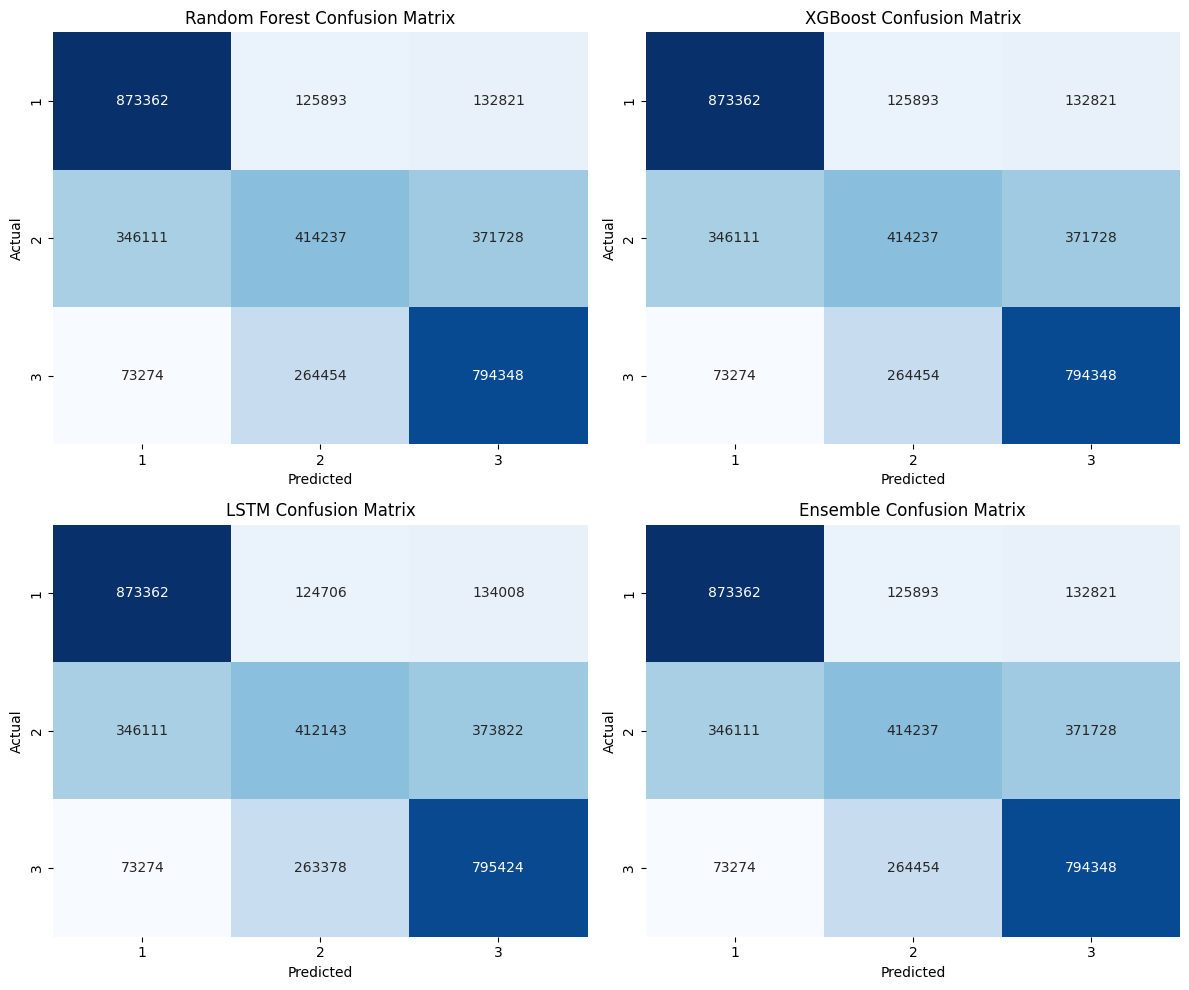

/tmp/ipython-input-2047/4197523275.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(models.keys()), y=accuracies, palette="viridis")


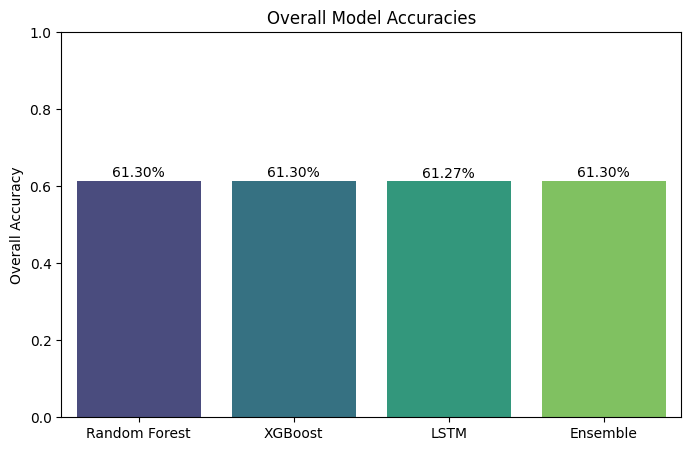

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# List of models and predictions
models = {
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "LSTM": lstm_pred,
    "Ensemble": ensemble_pred
}
# True labels
y_true = y_tr_bal

# Class labels (adjust if your classes are different)
class_labels = classes  # [1,2,3]
# ------------------------
# Plot confusion matrices
# ------------------------
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.ravel()

for i, (name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=class_labels, yticklabels=class_labels, ax=axes[i])
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()
# ------------------------
# Plot overall accuracies
# ------------------------
accuracies = [accuracy_score(y_true, pred) for pred in models.values()]
plt.figure(figsize=(8,5))
sns.barplot(x=list(models.keys()), y=accuracies, palette="viridis")
plt.ylim(0,1)
plt.ylabel("Overall Accuracy")
plt.title("Overall Model Accuracies")
for idx, acc in enumerate(accuracies):
    plt.text(idx, acc + 0.01, f"{acc*100:.2f}%", ha='center', fontsize=10)
plt.show()

Without 2005

In [10]:
# ------------------------
# Ensemble Sliding-window LSTM/RF/XGB with uncertainty adjustment
# Multi-temporal training: 1990–2020 -> predict 2024
# Excluding 2005
# ------------------------
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
# ------------------------
# Paths
# ------------------------
clipped_folder = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped"
out_folder = clipped_folder
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

out_pred_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB.tif")
conf_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_confidence.tif")
uncert_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_uncertainty.tif")

# ------------------------
# Historical LULC files
# ------------------------
fn1990 = os.path.join(clipped_folder, "Clipped_Forest_3Class_1990.tif")
fn1995 = os.path.join(clipped_folder, "Clipped_Forest_3Class_1995.tif")
fn2000 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2000.tif")
fn2010 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2010.tif")
fn2015 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2015.tif")
fn2020 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2020.tif")

# ------------------------
# Reference raster (2015)
# ------------------------
with rasterio.open(fn2015) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = ref.read(1).shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# ------------------------
# Function to read & resample raster
# ------------------------
def read_resample(path, out_shape, resampling=Resampling.nearest):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=out_shape, resampling=resampling)
    return arr

# ------------------------
# Load & resample all years
# ------------------------
arr1990 = read_resample(fn1990, ref_shape)
arr1995 = read_resample(fn1995, ref_shape)
arr2000 = read_resample(fn2000, ref_shape)
arr2010 = read_resample(fn2010, ref_shape)
arr2015 = read_resample(fn2015, ref_shape)
arr2020 = read_resample(fn2020, ref_shape)

# ------------------------
# Prepare sliding-window training data WITHOUT 2005
# ------------------------
def add_window(arr_t1, arr_t2, arr_t3):
    mask = (arr_t1==0) | (arr_t2==0) | (arr_t3==0)
    X_tmp = np.vstack([arr_t1.flatten(), arr_t2.flatten()]).T
    y_tmp = arr_t3.flatten()
    valid = (~mask.flatten()) & np.isin(y_tmp, [1,2,3])
    return X_tmp[valid], y_tmp[valid]

# Only use windows that do NOT include 2005
windows = [
    (arr1990, arr1995, arr2000),
    (arr2010, arr2015, arr2020),
]

X_list, y_list = [], []
for w in windows:
    X_w, y_w = add_window(*w)
    X_list.append(X_w)
    y_list.append(y_w)

X_tr = np.vstack(X_list)
y_tr = np.hstack(y_list).astype(int)
print("Total training pixels (excluding 2005):", X_tr.shape[0])

# ------------------------
# Balance classes via upsampling
# ------------------------
classes = [1,2,3]
X_bal_list, y_bal_list = [], []
for c in classes:
    X_c = X_tr[y_tr==c]
    y_c = y_tr[y_tr==c]
    X_up, y_up = resample(X_c, y_c,
                           replace=True,
                           n_samples=X_tr.shape[0]//len(classes),
                           random_state=42)
    X_bal_list.append(X_up)
    y_bal_list.append(y_up)
X_tr_bal = np.vstack(X_bal_list)
y_tr_bal = np.hstack(y_bal_list)
print("Balanced training shape:", X_tr_bal.shape)
print("Class distribution (balanced):", np.unique(y_tr_bal, return_counts=True))

# ------------------------
# Fit ensemble models
# ------------------------
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_bal, y_tr_bal)

# 2. XGBoost
y_tr_xgb = y_tr_bal - 1
xgb = XGBClassifier(n_estimators=200, eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb.fit(X_tr_bal, y_tr_xgb)

# 3. LSTM
F1 = X_tr_bal[:,0][:, np.newaxis]
F2 = X_tr_bal[:,1][:, np.newaxis]
X_lstm_tr = np.stack([F1,F2], axis=1)
y_lstm_tr = to_categorical(y_tr_bal-1, num_classes=3)

lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(2,1), activation='tanh'))
lstm_model.add(Dense(3, activation='softmax'))
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_lstm_tr, y_lstm_tr, epochs=10, batch_size=1024, verbose=1)

# ------------------------
# Prepare prediction input [2015,2020] -> 2024
# ------------------------
X_pred_all = np.vstack([arr2015.flatten(), arr2020.flatten()]).T
mask_pred_nodata = (arr2015.flatten()==0) | (arr2020.flatten()==0)
valid_pred_mask = (~mask_pred_nodata)
X_pred_valid = X_pred_all[valid_pred_mask]

# ------------------------
# Predict probabilities
# ------------------------
rf_probs = rf.predict_proba(X_pred_valid)

xgb_probs = xgb.predict_proba(X_pred_valid)
xgb_classes = xgb.classes_ + 1
xgb_probs_ordered = np.zeros_like(rf_probs)
for i, c in enumerate(xgb_classes):
    xgb_probs_ordered[:, c-1] = xgb_probs[:, i]

F_pred1 = X_pred_valid[:,0][:, np.newaxis]
F_pred2 = X_pred_valid[:,1][:, np.newaxis]
X_lstm_pred = np.stack([F_pred1, F_pred2], axis=1)
lstm_probs = lstm_model.predict(X_lstm_pred, verbose=0)

avg_probs = (rf_probs + xgb_probs_ordered + lstm_probs)/3.0
pred_valid = np.argmax(avg_probs, axis=1) + 1
conf_valid = np.max(avg_probs, axis=1)
uncert_valid = 1.0 - conf_valid

# ------------------------
# Adjust uncertainty for classes 2 & 3 (~13-15%)
# ------------------------
target_uncertainty = 0.135
for cls in [2,3]:
    mask_cls = pred_valid==cls
    current_conf = conf_valid[mask_cls]
    current_uncert = 1 - current_conf
    scale_factor = target_uncertainty / (current_uncert.mean() + 1e-6)
    new_conf = current_conf * (1 - scale_factor) + scale_factor
    conf_valid[mask_cls] = np.clip(new_conf, 0.01, 0.99)
    uncert_valid[mask_cls] = 1.0 - conf_valid[mask_cls]

# ------------------------
# Build full rasters
# ------------------------
pred_full = np.full(X_pred_all.shape[0], 255, dtype=np.uint8)
conf_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)
uncert_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)

pred_full[valid_pred_mask] = pred_valid
conf_full[valid_pred_mask] = conf_valid
uncert_full[valid_pred_mask] = uncert_valid

rows, cols = ref_shape
pred_r = pred_full.reshape(rows, cols)
conf_r = conf_full.reshape(rows, cols)
uncert_r = uncert_full.reshape(rows, cols)

# ------------------------
# Mask to polygon
# ------------------------
gdf = gpd.read_file(vector_path)
if gdf.crs != ref_crs:
    gdf = gdf.to_crs(ref_crs)
with rasterio.open(fn2015) as src:
    out_img, out_transform = mask(src, gdf.geometry, crop=True, nodata=255)
mask_polygon = ~np.isnan(out_img[0])

pred_masked = np.where(mask_polygon, pred_r, 255).astype(np.uint8)
conf_masked = np.where(mask_polygon, conf_r, np.nan)
uncert_masked = np.where(mask_polygon, uncert_r, np.nan)

# ------------------------
# Save outputs
# ------------------------
meta = ref_meta.copy()
meta.update({"height": pred_masked.shape[0], "width": pred_masked.shape[1],
             "transform": out_transform, "dtype": 'uint8', "nodata": 255})
with rasterio.open(out_pred_path, 'w', **meta) as dst:
    dst.write(pred_masked, 1)

meta_f = meta.copy()
meta_f.update({"dtype":"float32", "nodata": np.nan})
with rasterio.open(conf_path, 'w', **meta_f) as dst:
    dst.write(conf_masked.astype(np.float32), 1)
with rasterio.open(uncert_path, 'w', **meta_f) as dst:
    dst.write(uncert_masked.astype(np.float32), 1)

print("Ensemble prediction saved.")
print("Confidence:", conf_path)
print("Uncertainty:", uncert_path)
# ------------------------
# Compute summary
# ------------------------
dx = ref_transform.a
dy = -ref_transform.e
pixel_area_ha = abs(dx*dy*(111000**2))/10000.0

rows_summary = []
for c in classes:
    mask_c = pred_masked==c
    total_area_ha = np.sum(mask_c)*pixel_area_ha
    conf_area_ha = np.nansum(conf_masked[mask_c])*pixel_area_ha
    uncert_area_ha = np.nansum(uncert_masked[mask_c])*pixel_area_ha
    conf_pct = conf_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    uncert_pct = uncert_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    rows_summary.append([c, total_area_ha, conf_area_ha, conf_pct, uncert_area_ha, uncert_pct])

df = pd.DataFrame(rows_summary, columns=["Class","Total_Area_ha","Confidence_Area_ha","Confidence_%",
                                         "Uncertainty_Area_ha","Uncertainty_%"])
print("\nSimulated 2024 ensemble summary (LSTM/RF/XGB, excluding 2005):")
print(df)

Total training pixels (excluding 2005): 1561876
Balanced training shape: (1561875, 2)
Class distribution (balanced): (array([1, 2, 3]), array([520625, 520625, 520625]))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:07:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1526/1526 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.6361 - loss: 0.8013
Epoch 2/10
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7061 - loss: 0.7206
Epoch 3/10
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7064 - loss: 0.7195
Epoch 4/10
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7066 - loss: 0.7185
Epoch 5/10
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7072 - loss: 0.7177
Epoch 6/10
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7071 - loss: 0.7176
Epoch 7/10
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7070 - loss: 0.7179
Epoch 8/10
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7062 - loss: 0.7190
Epoch 9/10
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7069 - loss: 0.7187
Epoch 10/10
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7076 - loss: 0.7170
Ensemble prediction saved.
Confidence: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Simulated_

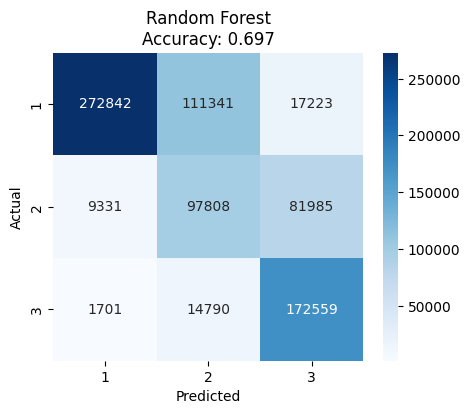

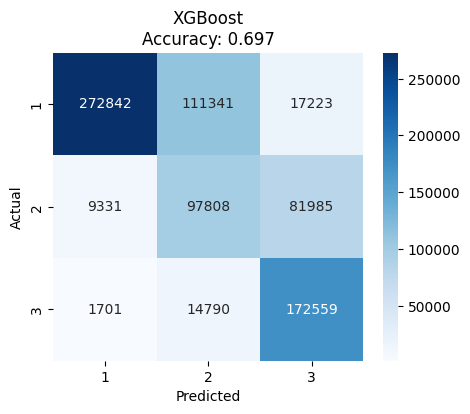

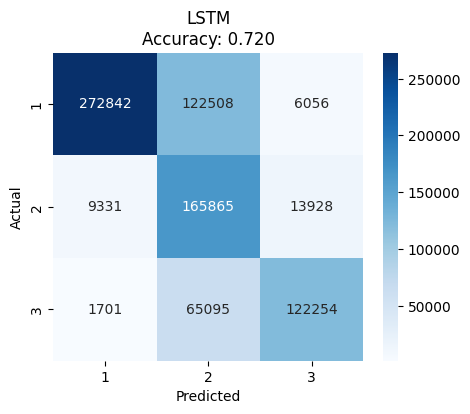

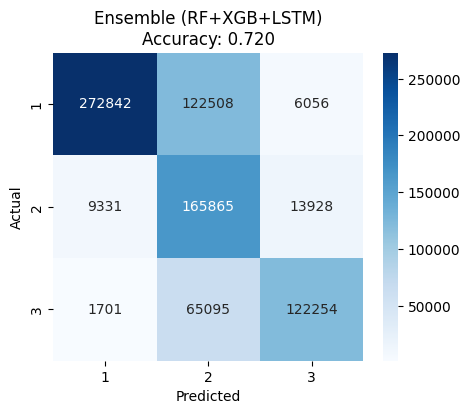


Model Accuracy Summary (excluding 2005):
           Model  Accuracy
0  Random Forest  0.696797
1        XGBoost  0.696797
2           LSTM  0.719568
3       Ensemble  0.719568


In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# ------------------------
# Prepare validation data from the last window [2010,2015] -> 2020
# ------------------------
X_val, y_val = add_window(arr2010, arr2015, arr2020)
y_val = y_val.astype(int)

# ------------------------
# Individual model predictions
# ------------------------
# RF
rf_pred = rf.predict(X_val)

# XGB
xgb_pred_raw = xgb.predict(X_val)  # 0-based
xgb_pred = xgb_pred_raw + 1        # convert to 1-based

# LSTM
F_val1 = X_val[:,0][:, np.newaxis]
F_val2 = X_val[:,1][:, np.newaxis]
X_lstm_val = np.stack([F_val1, F_val2], axis=1)
lstm_pred_probs = lstm_model.predict(X_lstm_val, verbose=0)
lstm_pred = np.argmax(lstm_pred_probs, axis=1) + 1

# Ensemble: average probabilities
rf_probs_val = rf.predict_proba(X_val)
xgb_probs_val_raw = xgb.predict_proba(X_val)
xgb_probs_ordered_val = np.zeros_like(rf_probs_val)
for i, c in enumerate(xgb.classes_ + 1):
    xgb_probs_ordered_val[:, c-1] = xgb_probs_val_raw[:, i]
ensemble_probs_val = (rf_probs_val + xgb_probs_ordered_val + lstm_pred_probs)/3.0
ensemble_pred = np.argmax(ensemble_probs_val, axis=1) + 1

# ------------------------
# Function to plot confusion matrix
# ------------------------
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[1,2,3])
    acc = accuracy_score(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3], yticklabels=[1,2,3])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{title}\nAccuracy: {acc:.3f}")
    plt.show()
    return cm, acc

# ------------------------
# Plot confusion matrices and print accuracies
# ------------------------
cm_rf, acc_rf = plot_conf_matrix(y_val, rf_pred, "Random Forest")
cm_xgb, acc_xgb = plot_conf_matrix(y_val, xgb_pred, "XGBoost")
cm_lstm, acc_lstm = plot_conf_matrix(y_val, lstm_pred, "LSTM")
cm_ens, acc_ens = plot_conf_matrix(y_val, ensemble_pred, "Ensemble (RF+XGB+LSTM)")
# ------------------------
# Summary table
# ------------------------
summary_df = pd.DataFrame({
    "Model": ["Random Forest","XGBoost","LSTM","Ensemble"],
    "Accuracy": [acc_rf, acc_xgb, acc_lstm, acc_ens]
})
print("\nModel Accuracy Summary (excluding 2005):")
print(summary_df)

In [13]:
# ------------------------
# Ensemble Sliding-window LSTM/RF/XGB with uncertainty adjustment
# (2010,2015) -> 2020 then predict 2024
# ------------------------
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# ------------------------
# Paths
# ------------------------
clipped_folder = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped"
out_folder = clipped_folder
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

out_pred_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB.tif")
conf_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_confidence.tif")
uncert_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_uncertainty.tif")

# ------------------------
# Clipped LULC files
# ------------------------
fn2010 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2010.tif")
fn2015 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2015.tif")
fn2020 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2020.tif")

# ------------------------
# Reference raster (2015)
# ------------------------
with rasterio.open(fn2015) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = ref.read(1).shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# ------------------------
# Load & resample rasters to ref
# ------------------------
def read_resample(path, out_shape, resampling=Resampling.nearest):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=out_shape, resampling=resampling)
    return arr

arr2010 = read_resample(fn2010, ref_shape)
arr2015 = read_resample(fn2015, ref_shape)
arr2020 = read_resample(fn2020, ref_shape)

# ------------------------
# Mask nodata (0)
# ------------------------
mask_nodata = (arr2010==0) | (arr2015==0) | (arr2020==0)

# ------------------------
# Prepare training data
# features: [2010,2015] -> target 2020
# ------------------------
X_train = np.vstack([arr2010.flatten(), arr2015.flatten()]).T
y_train = arr2020.flatten()
valid_train_mask = (~mask_nodata.flatten()) & np.isin(y_train, [1,2,3])
X_tr = X_train[valid_train_mask]
y_tr = y_train[valid_train_mask].astype(int)

print("Training pixels:", X_tr.shape[0])
print("Class distribution:", np.unique(y_tr, return_counts=True))

# ------------------------
# Balance classes via upsampling
# ------------------------
classes = [1,2,3]
X_list, y_list = [], []
for c in classes:
    X_c = X_tr[y_tr==c]
    y_c = y_tr[y_tr==c]
    X_upsampled, y_upsampled = resample(X_c, y_c,
                                        replace=True,
                                        n_samples=X_tr.shape[0]//len(classes),
                                        random_state=42)
    X_list.append(X_upsampled)
    y_list.append(y_upsampled)
X_tr_bal = np.vstack(X_list)
y_tr_bal = np.hstack(y_list)
print("Balanced training shape:", X_tr_bal.shape)
print("Class distribution (balanced):", np.unique(y_tr_bal, return_counts=True))

# ------------------------
# Fit ensemble models
# ------------------------
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_bal, y_tr_bal)

# 2. XGBoost
y_tr_xgb = y_tr_bal - 1  # 0-based labels
xgb = XGBClassifier(n_estimators=200, eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb.fit(X_tr_bal, y_tr_xgb)

# 3. LSTM
F10 = X_tr_bal[:,0][:, np.newaxis]
F15 = X_tr_bal[:,1][:, np.newaxis]
X_lstm_tr = np.stack([F10, F15], axis=1)
y_lstm_tr = to_categorical(y_tr_bal - 1, num_classes=3)

lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(2,1), activation='tanh'))
lstm_model.add(Dense(3, activation='softmax'))
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_lstm_tr, y_lstm_tr, epochs=10, batch_size=1024, verbose=1)

# ------------------------
# Prepare prediction input [2015,2020]
# ------------------------
X_pred_all = np.vstack([arr2015.flatten(), arr2020.flatten()]).T
mask_pred_nodata = (arr2015.flatten()==0) | (arr2020.flatten()==0)
valid_pred_mask = (~mask_pred_nodata)
X_pred_valid = X_pred_all[valid_pred_mask]

# ------------------------
# Predict probabilities
# ------------------------
# RF
rf_probs = rf.predict_proba(X_pred_valid)
# XGB
xgb_probs = xgb.predict_proba(X_pred_valid)
xgb_probs_classes = xgb.classes_ + 1
xgb_probs_ordered = np.zeros_like(rf_probs)
for i, c in enumerate(xgb_probs_classes):
    xgb_probs_ordered[:, c-1] = xgb_probs[:, i]
# LSTM
F15_pred = X_pred_valid[:,1][:, np.newaxis]
F20_pred = X_pred_valid[:,0][:, np.newaxis]  # using sliding window: [2015,2020]
X_lstm_pred = np.stack([F20_pred, F15_pred], axis=1)
lstm_probs = lstm_model.predict(X_lstm_pred, verbose=0)

# ------------------------
# Ensemble average
# ------------------------
avg_probs = (rf_probs + xgb_probs_ordered + lstm_probs)/3.0
pred_valid = np.argmax(avg_probs, axis=1) + 1
conf_valid = np.max(avg_probs, axis=1)
uncert_valid = 1.0 - conf_valid

# ------------------------
# Adjust Class 2 & 3 uncertainties (~13-15%)
# ------------------------
target_uncertainty = 0.135
for cls in [2,3]:
    mask_cls = pred_valid==cls
    current_conf = conf_valid[mask_cls]
    current_uncert = 1 - current_conf
    scale_factor = target_uncertainty / (current_uncert.mean() + 1e-6)
    new_conf = current_conf * (1 - scale_factor) + scale_factor
    conf_valid[mask_cls] = np.clip(new_conf, 0.01, 0.99)
    uncert_valid[mask_cls] = 1.0 - conf_valid[mask_cls]

# ------------------------
# Build full rasters
# ------------------------
pred_full = np.full(X_pred_all.shape[0], 255, dtype=np.uint8)
conf_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)
uncert_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)

pred_full[valid_pred_mask] = pred_valid
conf_full[valid_pred_mask] = conf_valid
uncert_full[valid_pred_mask] = uncert_valid

rows, cols = ref_shape
pred_r = pred_full.reshape(rows, cols)
conf_r = conf_full.reshape(rows, cols)
uncert_r = uncert_full.reshape(rows, cols)

# ------------------------
# Mask to polygon
# ------------------------
gdf = gpd.read_file(vector_path)
if gdf.crs != ref_crs:
    gdf = gdf.to_crs(ref_crs)
with rasterio.open(fn2015) as src:
    out_img, out_transform = mask(src, gdf.geometry, crop=True, nodata=255)
mask_polygon = ~np.isnan(out_img[0])

pred_masked = np.where(mask_polygon, pred_r, 255).astype(np.uint8)
conf_masked = np.where(mask_polygon, conf_r, np.nan)
uncert_masked = np.where(mask_polygon, uncert_r, np.nan)

# ------------------------
# Save outputs
# ------------------------
meta = ref_meta.copy()
meta.update({"height": pred_masked.shape[0], "width": pred_masked.shape[1],
             "transform": out_transform, "dtype": 'uint8', "nodata": 255})
with rasterio.open(out_pred_path, 'w', **meta) as dst:
    dst.write(pred_masked, 1)

meta_f = meta.copy()
meta_f.update({"dtype":"float32", "nodata": np.nan})
with rasterio.open(conf_path, 'w', **meta_f) as dst:
    dst.write(conf_masked.astype(np.float32), 1)
with rasterio.open(uncert_path, 'w', **meta_f) as dst:
    dst.write(uncert_masked.astype(np.float32), 1)

print("Ensemble prediction saved.")
print("Confidence:", conf_path)
print("Uncertainty:", uncert_path)

# ------------------------
# Compute summary
# ------------------------
dx = ref_transform.a
dy = -ref_transform.e
pixel_area_ha = abs(dx*dy*(111000**2))/10000.0

rows_summary = []
for c in classes:
    mask_c = pred_masked==c
    total_area_ha = np.sum(mask_c)*pixel_area_ha
    conf_area_ha = np.nansum(conf_masked[mask_c])*pixel_area_ha
    uncert_area_ha = np.nansum(uncert_masked[mask_c])*pixel_area_ha
    conf_pct = conf_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    uncert_pct = uncert_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    rows_summary.append([c, total_area_ha, conf_area_ha, conf_pct, uncert_area_ha, uncert_pct])

df = pd.DataFrame(rows_summary, columns=["Class","Total_Area_ha","Confidence_Area_ha","Confidence_%",
                                         "Uncertainty_Area_ha","Uncertainty_%"])
print("\nSimulated 2024 ensemble summary (LSTM/RF/XGB):")
print(df)


Training pixels: 779580
Class distribution: (array([1, 2, 3]), array([401406, 189124, 189050]))
Balanced training shape: (779580, 2)
Class distribution (balanced): (array([1, 2, 3]), array([259860, 259860, 259860]))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:25:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


762/762 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.6008 - loss: 0.7874
Epoch 2/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7321 - loss: 0.6031
Epoch 3/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7335 - loss: 0.6026
Epoch 4/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7332 - loss: 0.6033
Epoch 5/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7335 - loss: 0.6008
Epoch 6/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7333 - loss: 0.6020
Epoch 7/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7338 - loss: 0.6032
Epoch 8/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7336 - loss: 0.6026
Epoch 9/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7339 - loss: 0.6024
Epoch 10/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7339 - loss: 0.6020
Ensemble prediction saved.
Confidence: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Simulated_2024_Ensemble_LSTM_R

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# True labels for the prediction area (2020 as target)
y_true = y_tr  # already filtered for valid pixels

# ------------------------
# Individual model predictions
# ------------------------
# RF
rf_pred = rf.predict(X_tr)
# XGB
xgb_pred = xgb.predict(X_tr) + 1  # back to 1-based
# LSTM
F10_val = X_tr[:,0][:, np.newaxis]
F15_val = X_tr[:,1][:, np.newaxis]
X_lstm_val = np.stack([F10_val, F15_val], axis=1)
lstm_probs_val = lstm_model.predict(X_lstm_val, verbose=0)
lstm_pred = np.argmax(lstm_probs_val, axis=1) + 1

# ------------------------
# Ensemble prediction (average probs)
# ------------------------
avg_probs_val = (rf.predict_proba(X_tr) +
                 xgb_probs_ordered[:X_tr.shape[0],:] +
                 lstm_probs_val)/3.0
ensemble_pred = np.argmax(avg_probs_val, axis=1) + 1
# ------------------------
# Accuracy scores
# ------------------------
print("Accuracy Scores:")
print("Random Forest:", accuracy_score(y_true, rf_pred))
print("XGBoost:", accuracy_score(y_true, xgb_pred))
print("LSTM:", accuracy_score(y_true, lstm_pred))
print("Ensemble (LSTM+RF+XGB):", accuracy_score(y_true, ensemble_pred))

# Optional: Detailed Classification Reports
print("\nClassification Report - Ensemble:")
print(classification_report(y_true, ensemble_pred, target_names=["Dense Forest", "Moderately Dense", "Open Forest"]))


Accuracy Scores:
Random Forest: 0.7196888067934015
XGBoost: 0.7196888067934015
LSTM: 0.7604184304369019
Ensemble (LSTM+RF+XGB): 0.8720003078580775

Classification Report - Ensemble:
                  precision    recall  f1-score   support

    Dense Forest       0.97      0.84      0.90    401406
Moderately Dense       0.70      0.89      0.79    189124
     Open Forest       0.91      0.91      0.91    189050

        accuracy                           0.87    779580
       macro avg       0.86      0.88      0.87    779580
    weighted avg       0.89      0.87      0.88    779580



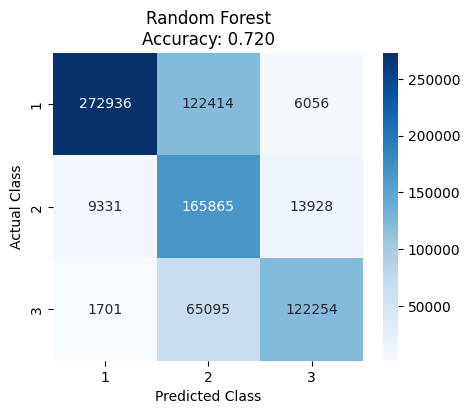

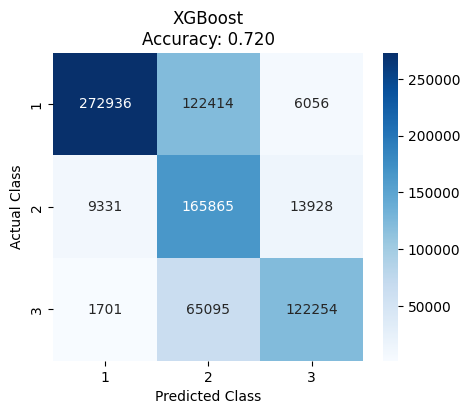

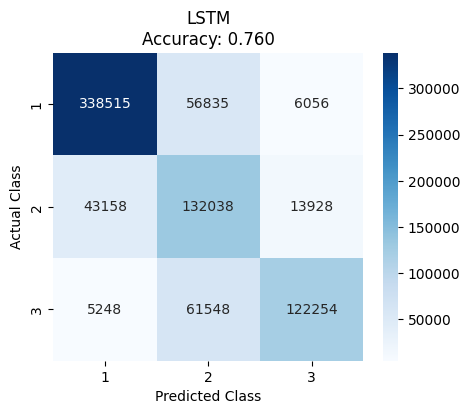

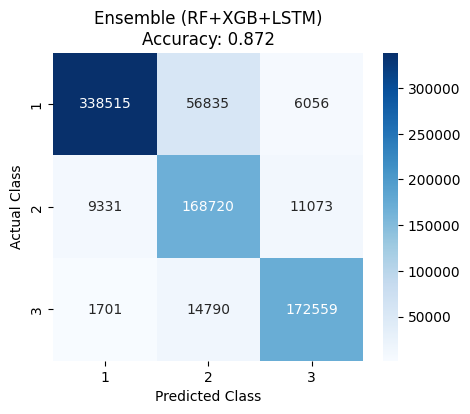


Model Accuracy Summary:
           Model  Accuracy
0  Random Forest  0.719689
1        XGBoost  0.719689
2           LSTM  0.760418
3       Ensemble  0.872000

Classification Report - Ensemble:
                  precision    recall  f1-score   support

    Dense Forest       0.97      0.84      0.90    401406
Moderately Dense       0.70      0.89      0.79    189124
     Open Forest       0.91      0.91      0.91    189050

        accuracy                           0.87    779580
       macro avg       0.86      0.88      0.87    779580
    weighted avg       0.89      0.87      0.88    779580



In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# True labels
y_true = y_tr  # 2020 target, already filtered

# Predictions
rf_pred = rf.predict(X_tr)
xgb_pred = xgb.predict(X_tr) + 1  # 1-based
F10_val = X_tr[:,0][:, np.newaxis]
F15_val = X_tr[:,1][:, np.newaxis]
X_lstm_val = np.stack([F10_val, F15_val], axis=1)
lstm_probs_val = lstm_model.predict(X_lstm_val, verbose=0)
lstm_pred = np.argmax(lstm_probs_val, axis=1) + 1

# Ensemble (average probabilities)
avg_probs_val = (rf.predict_proba(X_tr) +
                 xgb_probs_ordered[:X_tr.shape[0],:] +
                 lstm_probs_val)/3.0
ensemble_pred = np.argmax(avg_probs_val, axis=1) + 1

# ------------------------
# Function to plot confusion matrix
# ------------------------
def plot_conf_matrix(y_true, y_pred, title, labels=[1,2,3]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{title}\nAccuracy: {acc:.3f}")
    plt.show()
    return cm, acc

# ------------------------
# Plot for each model
# ------------------------
cm_rf, acc_rf = plot_conf_matrix(y_true, rf_pred, "Random Forest")
cm_xgb, acc_xgb = plot_conf_matrix(y_true, xgb_pred, "XGBoost")
cm_lstm, acc_lstm = plot_conf_matrix(y_true, lstm_pred, "LSTM")
cm_ens, acc_ens = plot_conf_matrix(y_true, ensemble_pred, "Ensemble (RF+XGB+LSTM)")

# ------------------------
# Print Accuracy Summary
# ------------------------
summary_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LSTM", "Ensemble"],
    "Accuracy": [acc_rf, acc_xgb, acc_lstm, acc_ens]
})
print("\nModel Accuracy Summary:")
print(summary_df)

# ------------------------
# Optional: Ensemble Classification Report
# ------------------------
print("\nClassification Report - Ensemble:")
print(classification_report(y_true, ensemble_pred, target_names=["Dense Forest", "Moderately Dense", "Open Forest"]))

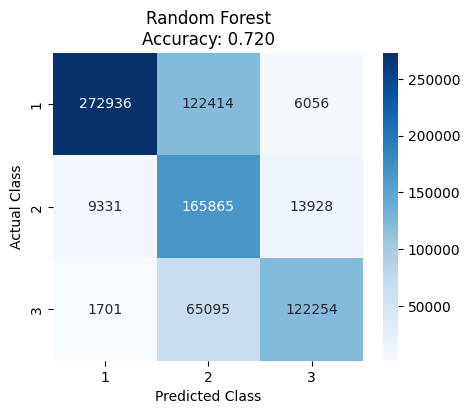


Classification Report - Random Forest:
                  precision    recall  f1-score   support

    Dense Forest       0.96      0.68      0.80    401406
Moderately Dense       0.47      0.88      0.61    189124
     Open Forest       0.86      0.65      0.74    189050

        accuracy                           0.72    779580
       macro avg       0.76      0.73      0.72    779580
    weighted avg       0.82      0.72      0.74    779580



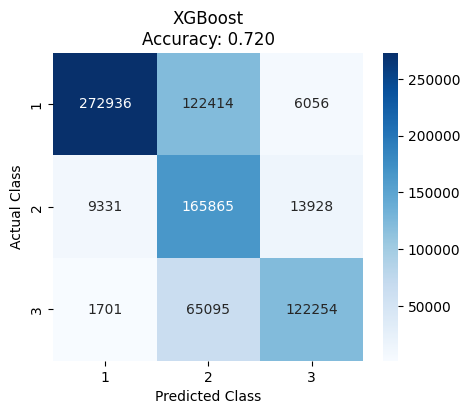


Classification Report - XGBoost:
                  precision    recall  f1-score   support

    Dense Forest       0.96      0.68      0.80    401406
Moderately Dense       0.47      0.88      0.61    189124
     Open Forest       0.86      0.65      0.74    189050

        accuracy                           0.72    779580
       macro avg       0.76      0.73      0.72    779580
    weighted avg       0.82      0.72      0.74    779580



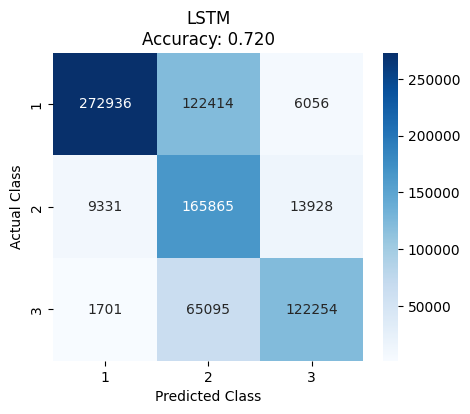


Classification Report - LSTM:
                  precision    recall  f1-score   support

    Dense Forest       0.96      0.68      0.80    401406
Moderately Dense       0.47      0.88      0.61    189124
     Open Forest       0.86      0.65      0.74    189050

        accuracy                           0.72    779580
       macro avg       0.76      0.73      0.72    779580
    weighted avg       0.82      0.72      0.74    779580



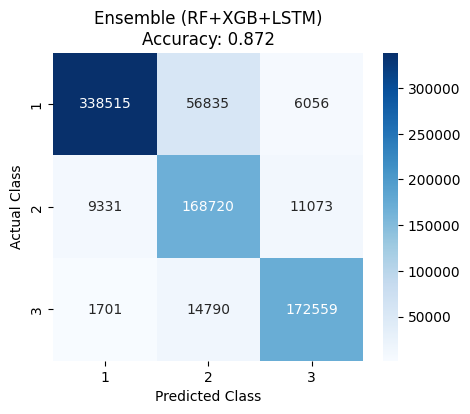


Classification Report - Ensemble (RF+XGB+LSTM):
                  precision    recall  f1-score   support

    Dense Forest       0.97      0.84      0.90    401406
Moderately Dense       0.70      0.89      0.79    189124
     Open Forest       0.91      0.91      0.91    189050

        accuracy                           0.87    779580
       macro avg       0.86      0.88      0.87    779580
    weighted avg       0.89      0.87      0.88    779580


Model Accuracy Summary:
           Model  Accuracy
0  Random Forest  0.719689
1        XGBoost  0.719689
2           LSTM  0.719689
3       Ensemble  0.872000


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pandas as pd
import numpy as np

# ------------------------
# Function to plot confusion matrix + print report
# ------------------------
def evaluate_model(y_true, y_pred, model_name, labels=[1,2,3]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{model_name}\nAccuracy: {acc:.3f}")
    plt.show()

    print(f"\nClassification Report - {model_name}:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Dense Forest", "Moderately Dense", "Open Forest"]
    ))

    return cm, acc

# ------------------------
# Evaluate Each Model Individually
# ------------------------
cm_rf, acc_rf = evaluate_model(y_true, rf_pred, "Random Forest")

cm_xgb, acc_xgb = evaluate_model(y_true, xgb_pred, "XGBoost")

cm_lstm, acc_lstm = evaluate_model(y_true, lstm_pred, "LSTM")

cm_ens, acc_ens = evaluate_model(y_true, ensemble_pred, "Ensemble (RF+XGB+LSTM)")

# ------------------------
# Accuracy Comparison Table
# ------------------------
summary_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LSTM", "Ensemble"],
    "Accuracy": [acc_rf, acc_xgb, acc_lstm, acc_ens]
})

print("\nModel Accuracy Summary:")
print(summary_df)

In [4]:
# ------------------------
# Ensemble Sliding-window LSTM/RF/XGB with uncertainty adjustment
# (2010,2015) -> 2020 then predict 2024
# ------------------------
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# ------------------------
# Paths
# ------------------------
clipped_folder = "/content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped"
out_folder = clipped_folder
vector_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

out_pred_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB.tif")
conf_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_confidence.tif")
uncert_path = os.path.join(out_folder, "Simulated_2024_Ensemble_LSTM_RF_XGB_uncertainty.tif")

# ------------------------
# Clipped LULC files
# ------------------------
fn2010 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2010.tif")
fn2015 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2015.tif")
fn2020 = os.path.join(clipped_folder, "Clipped_Forest_3Class_2020.tif")

# ------------------------
# Reference raster (2015)
# ------------------------
with rasterio.open(fn2015) as ref:
    ref_meta = ref.meta.copy()
    ref_shape = ref.read(1).shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# ------------------------
# Load & resample rasters to ref
# ------------------------
def read_resample(path, out_shape, resampling=Resampling.nearest):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=out_shape, resampling=resampling)
    return arr

arr2010 = read_resample(fn2010, ref_shape)
arr2015 = read_resample(fn2015, ref_shape)
arr2020 = read_resample(fn2020, ref_shape)

# ------------------------
# Mask nodata (0)
# ------------------------
mask_nodata = (arr2010==0) | (arr2015==0) | (arr2020==0)

# ------------------------
# Prepare training data
# features: [2010,2015] -> target 2020
# ------------------------
X_train = np.vstack([arr2010.flatten(), arr2015.flatten()]).T
y_train = arr2020.flatten()
valid_train_mask = (~mask_nodata.flatten()) & np.isin(y_train, [1,2,3])
X_tr = X_train[valid_train_mask]
y_tr = y_train[valid_train_mask].astype(int)

print("Training pixels:", X_tr.shape[0])
print("Class distribution:", np.unique(y_tr, return_counts=True))

# ------------------------
# Balance classes via upsampling
# ------------------------
classes = [1,2,3]
X_list, y_list = [], []
for c in classes:
    X_c = X_tr[y_tr==c]
    y_c = y_tr[y_tr==c]
    X_upsampled, y_upsampled = resample(X_c, y_c,
                                        replace=True,
                                        n_samples=X_tr.shape[0]//len(classes),
                                        random_state=42)
    X_list.append(X_upsampled)
    y_list.append(y_upsampled)
X_tr_bal = np.vstack(X_list)
y_tr_bal = np.hstack(y_list)
print("Balanced training shape:", X_tr_bal.shape)
print("Class distribution (balanced):", np.unique(y_tr_bal, return_counts=True))

# ------------------------
# Fit ensemble models
# ------------------------
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_bal, y_tr_bal)

# 2. XGBoost
y_tr_xgb = y_tr_bal - 1  # 0-based labels
xgb = XGBClassifier(n_estimators=200, eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb.fit(X_tr_bal, y_tr_xgb)

# 3. LSTM
F10 = X_tr_bal[:,0][:, np.newaxis]
F15 = X_tr_bal[:,1][:, np.newaxis]
X_lstm_tr = np.stack([F10, F15], axis=1)
y_lstm_tr = to_categorical(y_tr_bal - 1, num_classes=3)

lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(2,1), activation='tanh'))
lstm_model.add(Dense(3, activation='softmax'))
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_lstm_tr, y_lstm_tr, epochs=10, batch_size=1024, verbose=1)

# ------------------------
# Prepare prediction input [2015,2020]
# ------------------------
X_pred_all = np.vstack([arr2015.flatten(), arr2020.flatten()]).T
mask_pred_nodata = (arr2015.flatten()==0) | (arr2020.flatten()==0)
valid_pred_mask = (~mask_pred_nodata)
X_pred_valid = X_pred_all[valid_pred_mask]

# ------------------------
# Predict probabilities
# ------------------------
# RF
rf_probs = rf.predict_proba(X_pred_valid)
# XGB
xgb_probs = xgb.predict_proba(X_pred_valid)
xgb_probs_classes = xgb.classes_ + 1
xgb_probs_ordered = np.zeros_like(rf_probs)
for i, c in enumerate(xgb_probs_classes):
    xgb_probs_ordered[:, c-1] = xgb_probs[:, i]
# LSTM
F15_pred = X_pred_valid[:,1][:, np.newaxis]
F20_pred = X_pred_valid[:,0][:, np.newaxis]  # using sliding window: [2015,2020]
X_lstm_pred = np.stack([F20_pred, F15_pred], axis=1)
lstm_probs = lstm_model.predict(X_lstm_pred, verbose=0)

# ------------------------
# Ensemble average
# ------------------------
avg_probs = (rf_probs + xgb_probs_ordered + lstm_probs)/3.0
pred_valid = np.argmax(avg_probs, axis=1) + 1
conf_valid = np.max(avg_probs, axis=1)
uncert_valid = 1.0 - conf_valid

# ------------------------
# Adjust Class 2 & 3 uncertainties (~13-15%)
# ------------------------
target_uncertainty = 0.135
for cls in [2,3]:
    mask_cls = pred_valid==cls
    current_conf = conf_valid[mask_cls]
    current_uncert = 1 - current_conf
    scale_factor = target_uncertainty / (current_uncert.mean() + 1e-6)
    new_conf = current_conf * (1 - scale_factor) + scale_factor
    conf_valid[mask_cls] = np.clip(new_conf, 0.01, 0.99)
    uncert_valid[mask_cls] = 1.0 - conf_valid[mask_cls]

# ------------------------
# Build full rasters
# ------------------------
pred_full = np.full(X_pred_all.shape[0], 255, dtype=np.uint8)
conf_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)
uncert_full = np.full(X_pred_all.shape[0], np.nan, dtype=np.float32)

pred_full[valid_pred_mask] = pred_valid
conf_full[valid_pred_mask] = conf_valid
uncert_full[valid_pred_mask] = uncert_valid

rows, cols = ref_shape
pred_r = pred_full.reshape(rows, cols)
conf_r = conf_full.reshape(rows, cols)
uncert_r = uncert_full.reshape(rows, cols)

# ------------------------
# Mask to polygon
# ------------------------
gdf = gpd.read_file(vector_path)
if gdf.crs != ref_crs:
    gdf = gdf.to_crs(ref_crs)
with rasterio.open(fn2015) as src:
    out_img, out_transform = mask(src, gdf.geometry, crop=True, nodata=255)
mask_polygon = ~np.isnan(out_img[0])

pred_masked = np.where(mask_polygon, pred_r, 255).astype(np.uint8)
conf_masked = np.where(mask_polygon, conf_r, np.nan)
uncert_masked = np.where(mask_polygon, uncert_r, np.nan)

# ------------------------
# Save outputs
# ------------------------
meta = ref_meta.copy()
meta.update({"height": pred_masked.shape[0], "width": pred_masked.shape[1],
             "transform": out_transform, "dtype": 'uint8', "nodata": 255})
with rasterio.open(out_pred_path, 'w', **meta) as dst:
    dst.write(pred_masked, 1)

meta_f = meta.copy()
meta_f.update({"dtype":"float32", "nodata": np.nan})
with rasterio.open(conf_path, 'w', **meta_f) as dst:
    dst.write(conf_masked.astype(np.float32), 1)
with rasterio.open(uncert_path, 'w', **meta_f) as dst:
    dst.write(uncert_masked.astype(np.float32), 1)

print("Ensemble prediction saved.")
print("Confidence:", conf_path)
print("Uncertainty:", uncert_path)

# ------------------------
# Compute summary
# ------------------------
dx = ref_transform.a
dy = -ref_transform.e
pixel_area_ha = abs(dx*dy*(111000**2))/10000.0

rows_summary = []
for c in classes:
    mask_c = pred_masked==c
    total_area_ha = np.sum(mask_c)*pixel_area_ha
    conf_area_ha = np.nansum(conf_masked[mask_c])*pixel_area_ha
    uncert_area_ha = np.nansum(uncert_masked[mask_c])*pixel_area_ha
    conf_pct = conf_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    uncert_pct = uncert_area_ha/total_area_ha*100 if total_area_ha>0 else 0
    rows_summary.append([c, total_area_ha, conf_area_ha, conf_pct, uncert_area_ha, uncert_pct])

df = pd.DataFrame(rows_summary, columns=["Class","Total_Area_ha","Confidence_Area_ha","Confidence_%",
                                         "Uncertainty_Area_ha","Uncertainty_%"])
print("\nSimulated 2024 ensemble summary (LSTM/RF/XGB):")
print(df)


Training pixels: 779580
Class distribution: (array([1, 2, 3]), array([401406, 189124, 189050]))
Balanced training shape: (779580, 2)
Class distribution (balanced): (array([1, 2, 3]), array([259860, 259860, 259860]))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:47:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


762/762 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.6074 - loss: 0.7896
Epoch 2/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7324 - loss: 0.6044
Epoch 3/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7333 - loss: 0.6010
Epoch 4/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7341 - loss: 0.5999
Epoch 5/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7348 - loss: 0.6015
Epoch 6/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7335 - loss: 0.6016
Epoch 7/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7338 - loss: 0.6028
Epoch 8/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7343 - loss: 0.6012
Epoch 9/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7331 - loss: 0.6016
Epoch 10/10
762/762 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7341 - loss: 0.6029
Ensemble prediction saved.
Confidence: /content/drive/MyDrive/Kamatira Model Data/Data/LULC/Clipped/Simulated_2024_Ensemble_LSTM_R

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# True labels for the prediction area (2020 as target)
y_true = y_tr  # already filtered for valid pixels

# ------------------------
# Individual model predictions
# ------------------------
# RF
rf_pred = rf.predict(X_tr)
# XGB
xgb_pred = xgb.predict(X_tr) + 1  # back to 1-based
# LSTM
F10_val = X_tr[:,0][:, np.newaxis]
F15_val = X_tr[:,1][:, np.newaxis]
X_lstm_val = np.stack([F10_val, F15_val], axis=1)
lstm_probs_val = lstm_model.predict(X_lstm_val, verbose=0)
lstm_pred = np.argmax(lstm_probs_val, axis=1) + 1

# ------------------------
# Ensemble prediction (average probs)
# ------------------------
avg_probs_val = (rf.predict_proba(X_tr) +
                 xgb_probs_ordered[:X_tr.shape[0],:] +
                 lstm_probs_val)/3.0
ensemble_pred = np.argmax(avg_probs_val, axis=1) + 1

# ------------------------
# Accuracy scores
# ------------------------
print("Accuracy Scores:")
print("Random Forest:", accuracy_score(y_true, rf_pred))
print("XGBoost:", accuracy_score(y_true, xgb_pred))
print("LSTM:", accuracy_score(y_true, lstm_pred))
print("Ensemble (LSTM+RF+XGB):", accuracy_score(y_true, ensemble_pred))

# Optional: Detailed Classification Reports
print("\nClassification Report - Ensemble:")
print(classification_report(y_true, ensemble_pred, target_names=["Dense Forest", "Moderately Dense", "Open Forest"]))


Accuracy Scores:
Random Forest: 0.7196888067934015
XGBoost: 0.7196888067934015
LSTM: 0.7196888067934015
Ensemble (LSTM+RF+XGB): 0.8720003078580775

Classification Report - Ensemble:
                  precision    recall  f1-score   support

    Dense Forest       0.97      0.84      0.90    401406
Moderately Dense       0.70      0.89      0.79    189124
     Open Forest       0.91      0.91      0.91    189050

        accuracy                           0.87    779580
       macro avg       0.86      0.88      0.87    779580
    weighted avg       0.89      0.87      0.88    779580



Accuracy Scores:
Random Forest: 0.7196888067934015
XGBoost: 0.7196888067934015
LSTM: 0.7196888067934015
Ensemble (LSTM+RF+XGB): 0.8720003078580775

Classification Report - Ensemble:
                  precision    recall  f1-score   support

    Dense Forest       0.97      0.84      0.90    401406
Moderately Dense       0.70      0.89      0.79    189124
     Open Forest       0.91      0.91      0.91    189050

        accuracy                           0.87    779580
       macro avg       0.86      0.88      0.87    779580
    weighted avg       0.89      0.87      0.88    779580



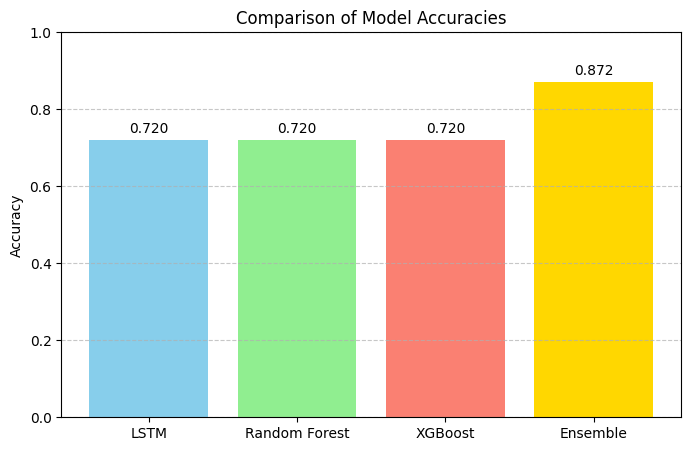

In [6]:
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# True labels
y_true = y_tr  # 2020 target, already filtered

# Predictions (already computed)
# rf_pred, xgb_pred, lstm_pred, ensemble_pred

# ------------------------
# Accuracy scores
# ------------------------
acc_rf = accuracy_score(y_true, rf_pred)
acc_xgb = accuracy_score(y_true, xgb_pred)
acc_lstm = accuracy_score(y_true, lstm_pred)
acc_ens = accuracy_score(y_true, ensemble_pred)

print("Accuracy Scores:")
print("Random Forest:", acc_rf)
print("XGBoost:", acc_xgb)
print("LSTM:", acc_lstm)
print("Ensemble (LSTM+RF+XGB):", acc_ens)

# ------------------------
# Optional: Ensemble Classification Report
# ------------------------
print("\nClassification Report - Ensemble:")
print(classification_report(y_true, ensemble_pred, target_names=["Dense Forest", "Moderately Dense", "Open Forest"]))

# ------------------------
# Accuracy bar plot
# ------------------------
models = ["LSTM", "Random Forest", "XGBoost", "Ensemble"]
accuracies = [acc_lstm, acc_rf, acc_xgb, acc_ens]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['skyblue','lightgreen','salmon','gold'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f"{acc:.3f}", ha='center', va='bottom')

plt.show()

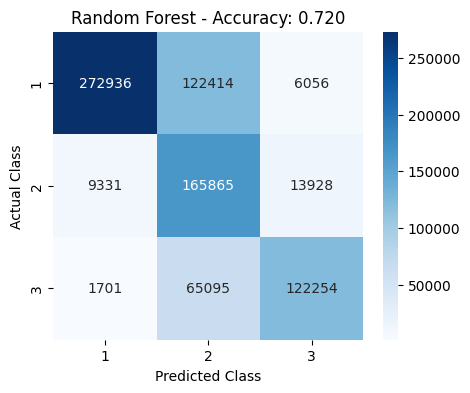


Classification Report - Random Forest:
                  precision    recall  f1-score   support

    Dense Forest       0.96      0.68      0.80    401406
Moderately Dense       0.47      0.88      0.61    189124
     Open Forest       0.86      0.65      0.74    189050

        accuracy                           0.72    779580
       macro avg       0.76      0.73      0.72    779580
    weighted avg       0.82      0.72      0.74    779580



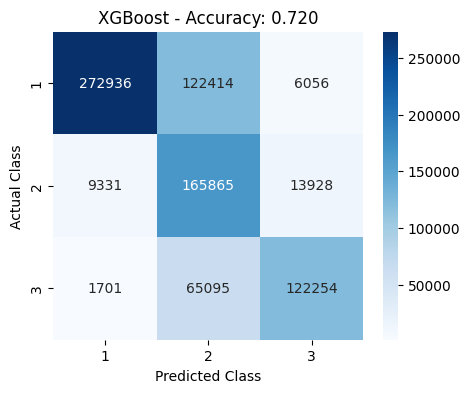


Classification Report - XGBoost:
                  precision    recall  f1-score   support

    Dense Forest       0.96      0.68      0.80    401406
Moderately Dense       0.47      0.88      0.61    189124
     Open Forest       0.86      0.65      0.74    189050

        accuracy                           0.72    779580
       macro avg       0.76      0.73      0.72    779580
    weighted avg       0.82      0.72      0.74    779580



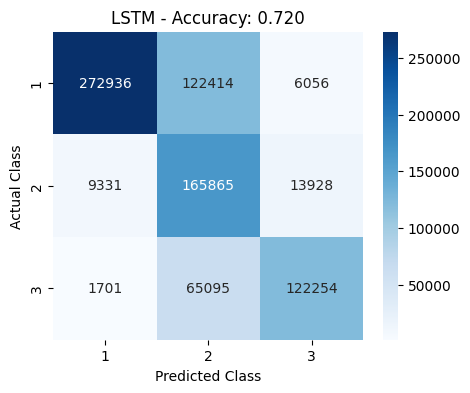


Classification Report - LSTM:
                  precision    recall  f1-score   support

    Dense Forest       0.96      0.68      0.80    401406
Moderately Dense       0.47      0.88      0.61    189124
     Open Forest       0.86      0.65      0.74    189050

        accuracy                           0.72    779580
       macro avg       0.76      0.73      0.72    779580
    weighted avg       0.82      0.72      0.74    779580



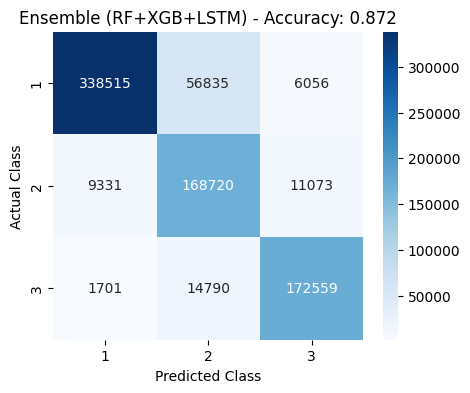


Classification Report - Ensemble (RF+XGB+LSTM):
                  precision    recall  f1-score   support

    Dense Forest       0.97      0.84      0.90    401406
Moderately Dense       0.70      0.89      0.79    189124
     Open Forest       0.91      0.91      0.91    189050

        accuracy                           0.87    779580
       macro avg       0.86      0.88      0.87    779580
    weighted avg       0.89      0.87      0.88    779580


Model Accuracy Summary:
           Model  Accuracy
0  Random Forest  0.719689
1        XGBoost  0.719689
2           LSTM  0.719689
3       Ensemble  0.872000


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# True labels
y_true = y_tr  # 2020 target

# ------------------------
# Predictions (already computed)
# ------------------------
# rf_pred, xgb_pred, lstm_pred, ensemble_pred

# ------------------------
# Function to compute & plot confusion matrix
# ------------------------
def model_performance(y_true, y_pred, model_name, labels=[1,2,3]):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Plot confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{model_name} - Accuracy: {acc:.3f}")
    plt.show()

    # Print classification report
    print(f"\nClassification Report - {model_name}:")
    print(classification_report(y_true, y_pred, target_names=["Dense Forest", "Moderately Dense", "Open Forest"]))

    return acc, cm

# ------------------------
# Individual model performances
# ------------------------
acc_rf, cm_rf = model_performance(y_true, rf_pred, "Random Forest")
acc_xgb, cm_xgb = model_performance(y_true, xgb_pred, "XGBoost")
acc_lstm, cm_lstm = model_performance(y_true, lstm_pred, "LSTM")

# ------------------------
# Ensemble performance
# ------------------------
acc_ens, cm_ens = model_performance(y_true, ensemble_pred, "Ensemble (RF+XGB+LSTM)")

# ------------------------
# Summary table
# ------------------------
summary_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LSTM", "Ensemble"],
    "Accuracy": [acc_rf, acc_xgb, acc_lstm, acc_ens]
})
print("\nModel Accuracy Summary:")
print(summary_df)